# ⏱️ Practical 3 — Time Series Detective
## Trend, seasonality, lags and decomposition

Energy data is not just a table with timestamps. In a **time series**, order matters: what happens now is often related to what happened one hour, one day, or one week ago.

In this practical we work with **hourly Estonian electricity consumption** and use an LLM as a research partner — not as an oracle.

### Learning outcomes

By the end of the practical you should be able to:

- distinguish ordinary timestamped data from a time series;
- check whether a time index is suitable for time-series analysis;
- detect daily and weekly patterns in electricity demand;
- create and interpret lag features;
- use rolling statistics to reveal local structure;
- explain the difference between causal and non-causal features;
- decompose a time series into trend, seasonality and remainder;
- use an LLM to generate hypotheses, code ideas and explanations;
- **verify LLM claims with data**.



# 0. The question

Imagine that tomorrow you need to build a model for Estonian electricity demand.

Before choosing a model, you need to understand the structure of the signal:

- Does demand repeat every day?
- Are weekdays different from weekends?
- Is yesterday useful for predicting today?
- Is last week useful for predicting this week?
- Is there a trend?
- Which operations would accidentally use information from the future?

We will answer these questions step by step.

## 🤔 Before touching the data — make a prediction

Discuss with a partner for 2–3 minutes.

For **hourly national electricity consumption**, rank these as predictors of the current hour:

1. demand **1 hour ago**;
2. demand **24 hours ago**;
3. demand **168 hours ago** (same hour one week ago).

Write your expected ranking and one sentence explaining why.

> ✍️ **Human prediction:**  
> `...`

## 🤖 LLM checkpoint 1 — ask for hypotheses, not answers

Ask an LLM something like:

> I have one year of hourly electricity demand data for Estonia.  
> Before seeing the data, propose three plausible temporal patterns I should expect.  
> For each pattern, suggest one simple Pandas-based test.  
> Do not invent numerical results.

Compare its hypotheses with yours.

> ✍️ **One useful LLM hypothesis:**  
> `...`
>
> ✍️ **One claim that still needs evidence:**  
> `...`

# 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

print("pandas:", pd.__version__)

pandas: 2.2.3


# 2. Load Estonian electricity demand

We use the same Elering 2022 dataset as in the previous course material.

The cell first looks for the file locally. If it cannot find it, it tries the public course repository.

In [2]:
filename = "electricity-production and consumption_2022.csv"

local_candidates = [
    Path("data") / filename,
    Path(filename),                 # when the CSV is next to the notebook
]

data_source = next((p for p in local_candidates if p.exists()), None)

if data_source is not None:
    raw = pd.read_csv(data_source, delimiter=";", decimal=",")
    print("Loaded local file:", data_source)
else:
    url = (
        "https://raw.githubusercontent.com/"
        "drmatson/energy_informatics/main/data/"
        "electricity-production%20and%20consumption_2022.csv"
    )
    raw = pd.read_csv(url, delimiter=";", decimal=",")
    print("Loaded public course data from GitHub")

raw.head()

Loaded public course data from GitHub


,Ajatempel (UTC),Kuupaev (Eesti aeg),Tarbimine,Tootmine,Planeeritud tarbimine,Planeeritud tootmine
0,1640988000,01.01.2022 00:00,899.4,419.5,903.1,462.4
1,1640991600,01.01.2022 01:00,892.1,431.9,935.8,469.1
2,1640995200,01.01.2022 02:00,874.3,428.1,897.6,458.6
3,1640998800,01.01.2022 03:00,860.1,435.7,878.5,471.9
4,1641002400,01.01.2022 04:00,842.7,429.2,891.1,472.2


## 🐼 Your turn — inspect before transforming

You already know Pandas, so there is no guided tour here.

Use a few familiar commands to answer:

- How many rows and columns are there?
- What are the column names?
- Which columns are numeric?
- Are there missing values?

Try to answer first with code, not with an LLM.

In [3]:
# YOUR CODE HERE

# 3. Build a proper time series

The source contains both UTC and Estonian local-time information. For this practical we use the human-readable Estonian timestamp and the measured consumption column.

A time-series index should be:

- parsed as datetime;
- sorted;
- free of duplicated timestamps for the intended analysis;
- checked for missing intervals.

In [4]:
demand = raw[["Kuupaev (Eesti aeg)", "Tarbimine"]].copy()

demand["timestamp"] = pd.to_datetime(
    demand["Kuupaev (Eesti aeg)"],
    dayfirst=True
)

demand = (
    demand[["timestamp", "Tarbimine"]]
    .rename(columns={"Tarbimine": "demand_MW"})
    .set_index("timestamp")
    .sort_index()
)

demand.head()

,demand_MW
timestamp,
2022-01-01 00:00:00,899.4
2022-01-01 01:00:00,892.1
2022-01-01 02:00:00,874.3
2022-01-01 03:00:00,860.1
2022-01-01 04:00:00,842.7


## 🕵️ Time-index audit

Complete the audit below.

Questions:

1. Is the index monotonic?
2. Are there duplicate timestamps?
3. What is the smallest and largest time difference between consecutive rows?
4. Why can daylight-saving time make local timestamps tricky?

In [5]:
print("Sorted:", demand.index.is_monotonic_increasing)
print("Duplicate timestamps:", demand.index.duplicated().sum())

time_steps = demand.index.to_series().diff().dropna()

print("Smallest step:", time_steps.min())
print("Largest step:", time_steps.max())
print("\nMost common steps:")
print(time_steps.value_counts().head())

Sorted: True
Duplicate timestamps: 0
Smallest step: 0 days 01:00:00
Largest step: 0 days 01:00:00

Most common steps:
timestamp
0 days 01:00:00    8759
Name: count, dtype: int64


### ⚠️ Important: a timestamp is not automatically a clean time axis

Local clock time can contain **DST irregularities**. A model that blindly assumes “every row = exactly one elapsed hour” can therefore be wrong around clock changes.

For today's exercises we keep the local timestamp because it makes hour-of-day patterns easy to interpret. In production forecasting, time zones and DST must be handled explicitly.

## 🤖 LLM checkpoint 2 — make it explain the risk

Ask the LLM:

> Why can an hourly electricity dataset in local Estonian time contain a missing or duplicated clock hour around daylight-saving transitions?  
> Explain the modelling risk in 4–5 sentences.

Then judge the answer.

> ✍️ **What did the LLM explain well?**  
> `...`
>
> ✍️ **What would you still verify in the actual timestamps?**  
> `...`

# 4. First look: what structure can you see?

Never begin time-series analysis with a model. Begin with the signal.

In [6]:
import plotly.express as px

fig = px.line(
    demand,
    x=demand.index,
    y="demand_MW",
    title="Estonian electricity demand — 2022",
    labels={
        "timestamp": "Time",
        "demand_MW": "Demand [MW]"
    }
)

fig.show()


## 🐼 Zoom in

Plot only **two weeks** of data. Choose any two-week period.

Try to identify:

- repeated daily structure;
- differences between working days and weekends;
- unusual days or peaks.

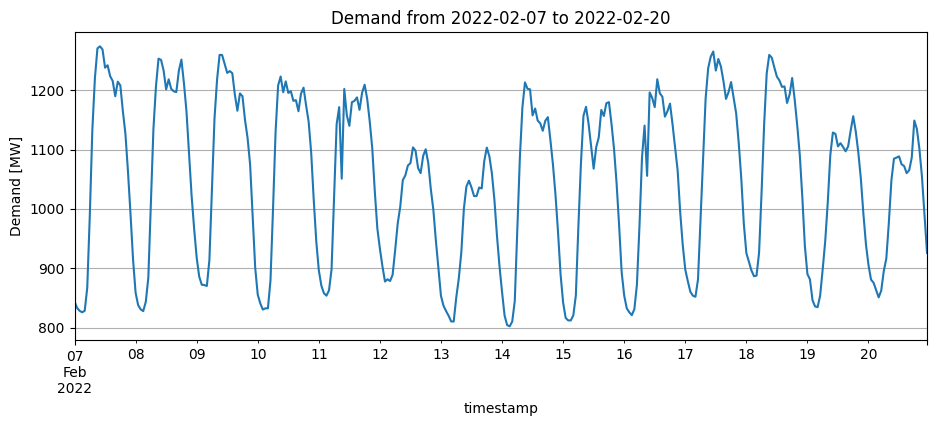

In [7]:
start = "2022-02-07"
end = "2022-02-20"

# Change the dates if you want to explore another period
demand.loc[start:end, "demand_MW"].plot(
    title=f"Demand from {start} to {end}",
    ylabel="Demand [MW]"
)
plt.show()

> ✍️ **Pattern 1:** `...`  
> ✍️ **Pattern 2:** `...`  
> ✍️ **Something surprising:** `...`

# 5. Turn visual impressions into tests

A plot suggests hypotheses. Aggregation helps test them.

## Hour-of-day profile

What does a “typical” day look like?

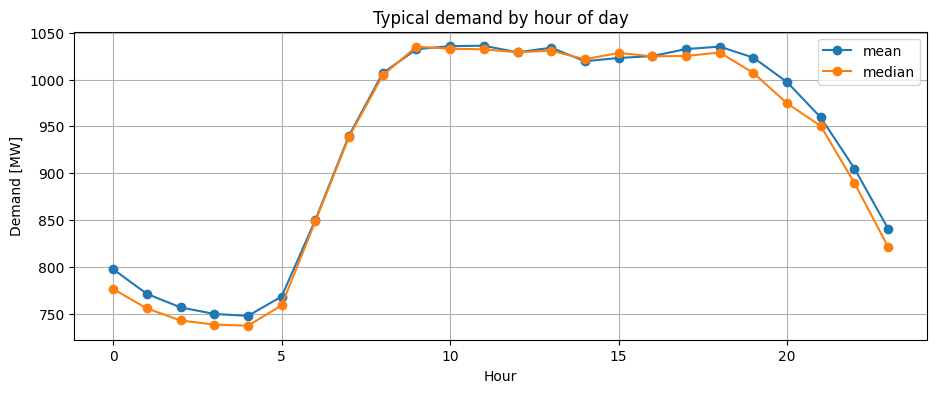

In [8]:
hourly_profile = demand.groupby(demand.index.hour)["demand_MW"].agg(["mean", "median"])

hourly_profile.plot(
    title="Typical demand by hour of day",
    xlabel="Hour",
    ylabel="Demand [MW]",
    marker="o"
)
plt.show()

## 🐼 Your turn — weekday profile

Create a table or plot of **mean demand by day of week**.

Hint:

```python
demand.index.dayofweek
```

uses `0 = Monday, ..., 6 = Sunday`.

Then answer:

> ✍️ Which days appear structurally different? `...`

In [9]:
# YOUR CODE HERE

## 🤖 LLM checkpoint 3 — interpretation under constraints

Give the LLM only the **hour-of-day table** you computed above and ask:

> Interpret this electricity-demand profile.  
> Give at most three possible explanations for the shape.  
> Clearly separate what is directly supported by the numbers from what is only a hypothesis.

This is a useful habit: make the model distinguish **observation** from **storytelling**.

> ✍️ Write one sentence the LLM treated as evidence and one it treated as hypothesis.

# 6. Lag detective 🔁

A **lag** is a past value aligned with the present row.

For hourly data:

- `lag1` = 1 hour ago;
- `lag24` = same clock hour roughly one day ago;
- `lag168` = same clock hour roughly one week ago.

Mathematically:

$
\mathrm{lag}_k(t)=y_{t-k}
$

The important word is **past**.

In [10]:
lagged = demand.copy()

lagged["lag1"] = lagged["demand_MW"].shift(1)
lagged["lag24"] = lagged["demand_MW"].shift(24)
lagged["lag168"] = lagged["demand_MW"].shift(168)

lagged.head(170)

,demand_MW,lag1,lag24,lag168
timestamp,,,,
2022-01-01 00:00:00,899.4,NaN,NaN,NaN
2022-01-01 01:00:00,892.1,899.4,NaN,NaN
2022-01-01 02:00:00,874.3,892.1,NaN,NaN
2022-01-01 03:00:00,860.1,874.3,NaN,NaN
2022-01-01 04:00:00,842.7,860.1,NaN,NaN
...,...,...,...,...
2022-01-07 21:00:00,1163.3,1223.3,1164.6,NaN
2022-01-07 22:00:00,1104.9,1163.3,1090.6,NaN
2022-01-07 23:00:00,1039.8,1104.9,1018.1,NaN


## 🤔 Human vs LLM prediction

Before computing correlations, write down:

> ✍️ **My expected winner:** `lag...`

Ask the LLM the same question **without showing the data**.

> ✍️ **LLM expected winner:** `lag...`

Now test both predictions.

In [11]:
lag_correlations = (
    lagged[["demand_MW", "lag1", "lag24", "lag168"]]
    .corr()["demand_MW"]
    .drop("demand_MW")
    .sort_values(ascending=False)
)

lag_correlations

,demand_MW
lag1,0.968081
lag168,0.895063
lag24,0.878906


### 🧠 Judge

- Which lag won?
- Did the result agree with you?
- Did it agree with the LLM?
- Does high correlation prove that the lag is always the best forecasting feature?

> ✍️ **Your conclusion:**  
> `...`

## 🐼 Visual verification

Correlation compresses thousands of observations into one number. Plotting helps you see what that number hides.

Choose a week and compare actual demand with `lag24` and `lag168`.

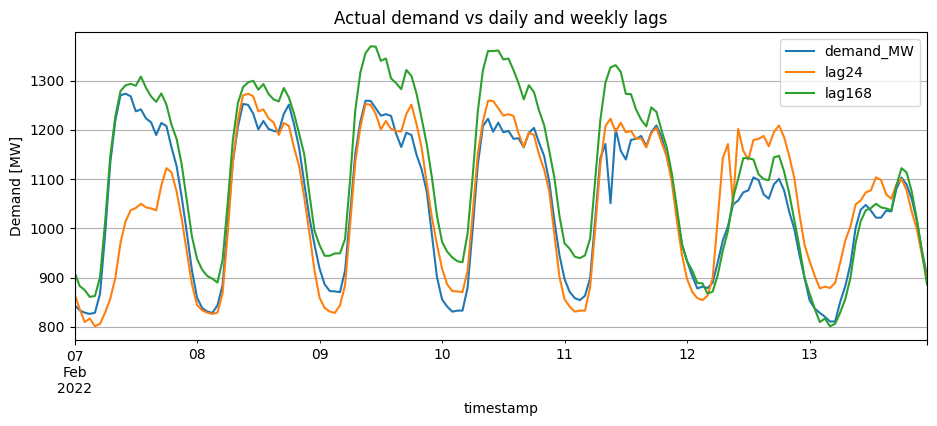

In [12]:
week = lagged.loc["2022-02-07":"2022-02-13", ["demand_MW", "lag24", "lag168"]]
week.plot(
    title="Actual demand vs daily and weekly lags",
    ylabel="Demand [MW]"
)
plt.show()

# 7. Rolling statistics: local memory instead of one past point

A lag asks:

> “What happened exactly \(k\) steps ago?”

A rolling statistic asks:

> “What was happening over the recent window?”

For a trailing rolling mean of width \(w\):

$
\bar y_t = \frac{1}{w}\sum_{i=0}^{w-1} y_{t-i}
$

For forecasting, the window must not use future observations.

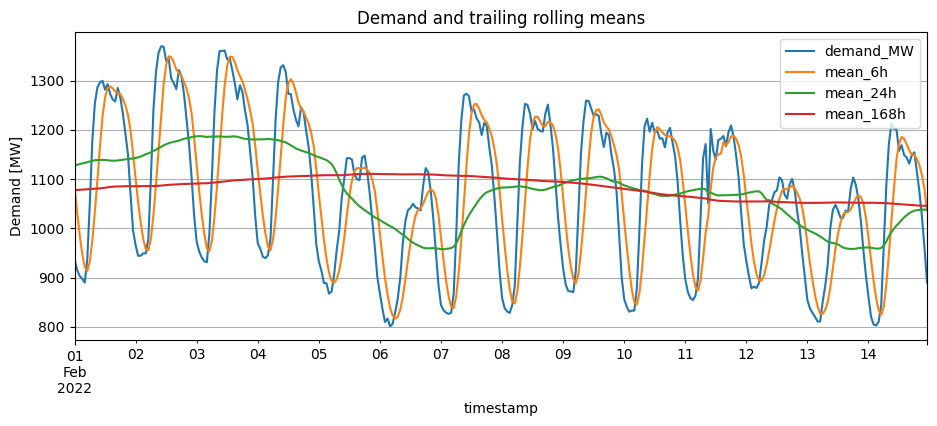

In [13]:
rolling = demand.copy()

rolling["mean_6h"] = rolling["demand_MW"].rolling(6).mean()
rolling["mean_24h"] = rolling["demand_MW"].rolling(24).mean()
rolling["mean_168h"] = rolling["demand_MW"].rolling(168).mean()

rolling.loc["2022-02-01":"2022-02-14"].plot(
    title="Demand and trailing rolling means",
    ylabel="Demand [MW]"
)
plt.show()

## 🎛️ Parameter experiment

Change only `WINDOW` and rerun the cell.

Try at least:

- `6`
- `24`
- `72`
- `168`

What disappears as the window grows? What remains?

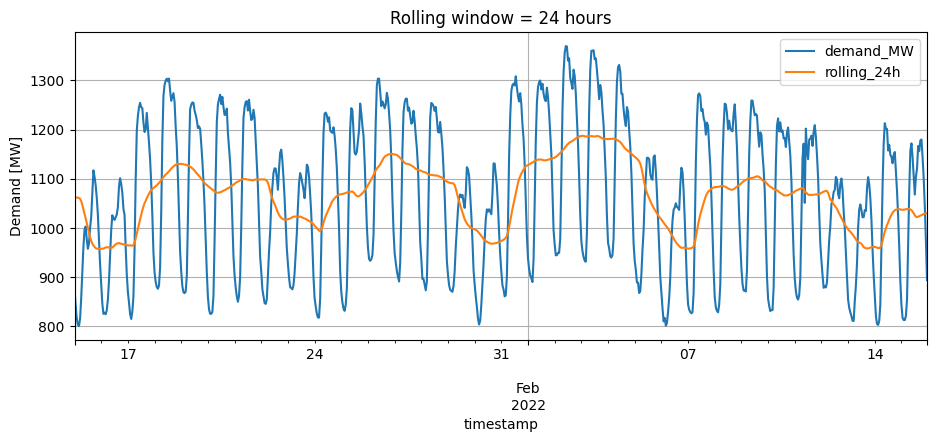

In [14]:
WINDOW = 24

tmp = demand["demand_MW"].to_frame()
tmp[f"rolling_{WINDOW}h"] = tmp["demand_MW"].rolling(WINDOW).mean()

tmp.loc["2022-01-15":"2022-02-15"].plot(
    title=f"Rolling window = {WINDOW} hours",
    ylabel="Demand [MW]"
)
plt.show()

> ✍️ **Small window:** `...`  
> ✍️ **Large window:** `...`  
> ✍️ **Which window would you use to show a weekly baseline, and why?** `...`

# 8. Leakage trap 🚨

Consider two features:

```python
A = demand["demand_MW"].rolling(24).mean()

B = demand["demand_MW"].rolling(24, center=True).mean()
```

Suppose the feature is used to predict demand at time $t$.

## 🤔 Decide before running anything

Which feature is safer for forecasting: **A or B**? Why?

> ✍️ `...`

## 🤖 Ask the LLM to audit the code

Prompt:

> I want to forecast an hourly time series.  
> Audit these two Pandas rolling features for future-information leakage:
>
> `A = y.rolling(24).mean()`  
> `B = y.rolling(24, center=True).mean()`
>
> Explain exactly which timestamps each feature can use around time t.

Do **not** accept “A is safe” automatically. Ask one more question:

> If I am predicting $y_t$, should the rolling feature include $y_t$ itself?

This distinction becomes important later when we build forecasting datasets.

### 🧠 Key idea

For a feature used to predict the *same row's* target \(y_t\), even a trailing rolling mean may need an additional shift:

```python
safe_past_24h_mean = y.shift(1).rolling(24).mean()
```

Now the feature contains only information available **before** \(t\).

In [15]:
leakage_demo = demand[["demand_MW"]].copy()

leakage_demo["rolling_including_t"] = (
    leakage_demo["demand_MW"].rolling(24).mean()
)

leakage_demo["past_24h_mean"] = (
    leakage_demo["demand_MW"].shift(1).rolling(24).mean()
)

leakage_demo.head(28)

,demand_MW,rolling_including_t,past_24h_mean
timestamp,,,
2022-01-01 00:00:00,899.4,NaN,NaN
2022-01-01 01:00:00,892.1,NaN,NaN
2022-01-01 02:00:00,874.3,NaN,NaN
2022-01-01 03:00:00,860.1,NaN,NaN
2022-01-01 04:00:00,842.7,NaN,NaN
2022-01-01 05:00:00,844.7,NaN,NaN
2022-01-01 06:00:00,852.2,NaN,NaN
2022-01-01 07:00:00,868.4,NaN,NaN
2022-01-01 08:00:00,874.8,NaN,NaN


# 9. Decomposition 🧩

A common conceptual view is:

$
y_t = T_t + S_t + R_t
$

where:

- $T_t$ = trend;
- $S_t$ = seasonal component;
- $R_t$ = remainder.

For hourly electricity demand, there is more than one possible seasonal period. We will deliberately try two.

## Experiment A — daily period

Set `period=24`.

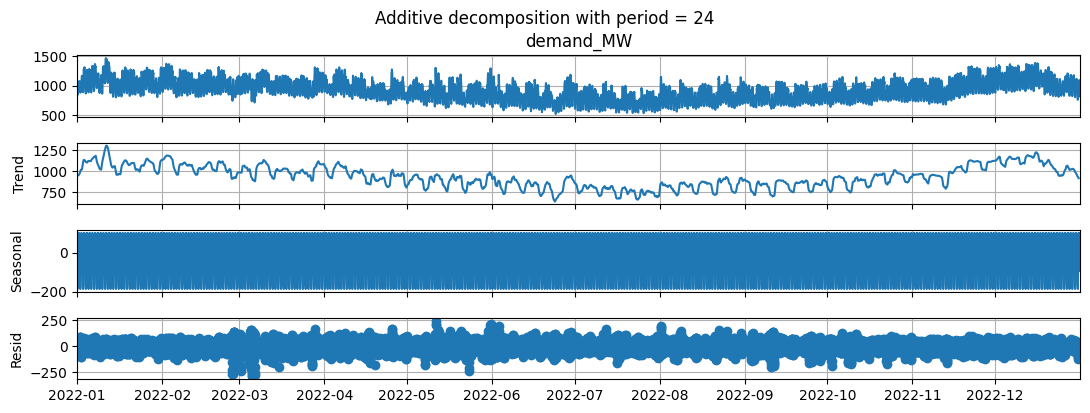

In [16]:
daily_decomposition = seasonal_decompose( demand["demand_MW"], model="additive", period=24 )
daily_decomposition.plot()
plt.suptitle("Additive decomposition with period = 24", y=1.02)
plt.show()

In [17]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

daily_decomposition = seasonal_decompose(
    demand["demand_MW"],
    model="additive",
    period=24
)

fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    subplot_titles=[
        "Observed",
        "Trend",
        "Seasonal",
        "Residual"
    ],
    vertical_spacing=0.06
)

fig.add_trace(
    go.Scatter(
        x=demand.index,
        y=daily_decomposition.observed,
        name="Observed"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=demand.index,
        y=daily_decomposition.trend,
        name="Trend"
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=demand.index,
        y=daily_decomposition.seasonal,
        name="Seasonal"
    ),
    row=3, col=1
)

fig.add_trace(
    go.Scatter(
        x=demand.index,
        y=daily_decomposition.resid,
        name="Residual"
    ),
    row=4, col=1
)

fig.update_layout(
    title="Additive decomposition with period = 24",
    height=800,
    showlegend=False
)

fig.update_xaxes(title_text="Time", row=4, col=1)

fig.show()

## Experiment B — weekly period

Set `period=168`.

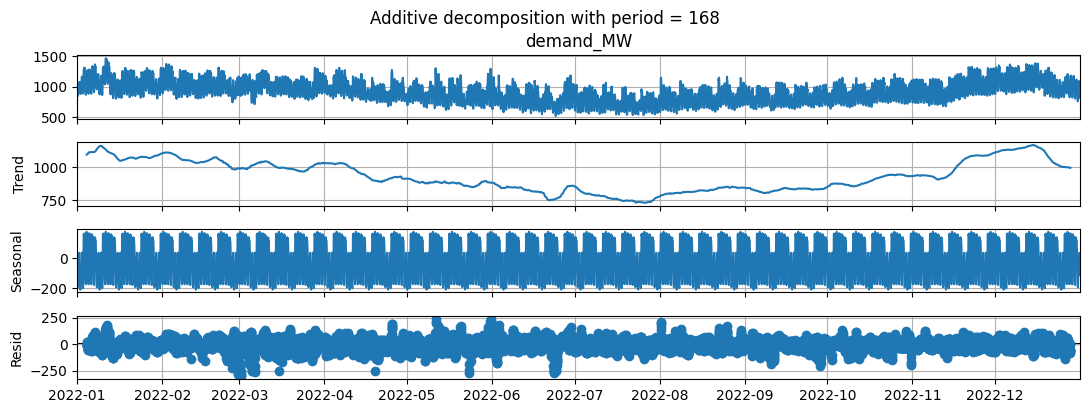

In [18]:
weekly_decomposition = seasonal_decompose( demand["demand_MW"], model="additive", period=168 )
weekly_decomposition.plot()
plt.suptitle("Additive decomposition with period = 168", y=1.02)
plt.show()

In [19]:


weekly_decomposition = seasonal_decompose(
    demand["demand_MW"],
    model="additive",
    period=168
)

fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    subplot_titles=[
        "Observed",
        "Trend",
        "Seasonal",
        "Residual"
    ],
    vertical_spacing=0.06
)

fig.add_trace(
    go.Scatter(
        x=demand.index,
        y=weekly_decomposition.observed,
        name="Observed"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=demand.index,
        y=weekly_decomposition.trend,
        name="Trend"
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=demand.index,
        y=weekly_decomposition.seasonal,
        name="Seasonal"
    ),
    row=3, col=1
)

fig.add_trace(
    go.Scatter(
        x=demand.index,
        y=weekly_decomposition.resid,
        name="Residual"
    ),
    row=4, col=1
)

fig.update_layout(
    title="Additive decomposition with period = 168",
    height=800,
    showlegend=False
)

fig.update_xaxes(title_text="Time", row=4, col=1)

fig.show()

## 🧠 Compare the two decompositions

Answer:

1. What structure is captured by `period=24`?
2. What changes with `period=168`?
3. Which period is “correct”?

The useful answer to question 3 is usually **not simply one number**. Real energy demand may contain multiple seasonalities at once.

> ✍️ **Your comparison:**  
> `...`

## 🤖 LLM checkpoint 4 — make it criticize your interpretation

Write your own 2–3 sentence interpretation first.

Then ask:

> Here is my interpretation of a daily and weekly decomposition of hourly electricity demand:  
> [paste your interpretation]  
>
> Act as a critical reviewer. Identify one statement that is well supported, one that is too strong, and one additional check I should perform.

Revise your interpretation only if the criticism is justified.

# 10. Additive or multiplicative?

Two common decompositions are:

$
y_t = T_t + S_t + R_t
$

and

$
y_t = T_t \times S_t \times R_t
$

A rough visual question is:

> Does seasonal amplitude stay approximately constant, or does it grow with the level of the series?

We will not turn this into a formal model-selection exercise today.

## 🐼 Your turn

Select two contrasting months (for example winter and summer), plot one or two weeks from each, and decide whether an additive interpretation looks reasonable.

> ✍️ **Evidence for/against additive seasonality:** `...`

In [20]:
# YOUR CODE HERE

# 11. From analysis to forecasting features

You are not building the forecasting model today. You are designing its **information set**.

Based on everything you observed, propose four candidate features for predicting hourly demand.

Examples of feature families:

- calendar features;
- lag features;
- rolling features;
- external variables such as weather.

For each feature, ask:

1. Is it known at forecast time?
2. Does it accidentally include the target or future data?
3. What physical or behavioral pattern is it trying to capture?

## 🤖 LLM challenge — feature engineer, then safety auditor

Use this two-stage prompt:

> **Stage 1 — Feature engineer:**  
> Propose 6 features for forecasting hourly Estonian electricity demand from historical demand and timestamps. Explain the purpose of each feature.
>
> **Stage 2 — Safety auditor:**  
> Now audit your own six features. Mark any feature that could leak future information depending on implementation, and explain how to construct it causally.

Do not just copy the answer. Build a small audit table yourself.

In [21]:
feature_audit = pd.DataFrame({
    "feature": [
        # "lag24",
        # ...
    ],
    "why_use_it": [
        # "captures daily repetition",
        # ...
    ],
    "available_at_prediction_time": [
        # True,
        # ...
    ],
    "leakage_risk": [
        # "low",
        # ...
    ],
})

feature_audit

,feature,why_use_it,available_at_prediction_time,leakage_risk


## 🐼 Implement two safe features

Choose any two features from your audit and add them to a new DataFrame called `model_data`.

Your implementation should use **past or known information only**.

In [22]:
model_data = demand.copy()

# YOUR CODE HERE

model_data.head()

,demand_MW
timestamp,
2022-01-01 00:00:00,899.4
2022-01-01 01:00:00,892.1
2022-01-01 02:00:00,874.3
2022-01-01 03:00:00,860.1
2022-01-01 04:00:00,842.7


# 12. Mini challenge — explain an unfamiliar week

Choose any seven-day period from 2022 that you did **not** use earlier.

Your goal is to create a short evidence-based description of its temporal structure.

Use at least **three** of the following:

- raw time-series plot;
- hour-of-day profile;
- day-of-week comparison;
- lag comparison;
- rolling statistic;
- decomposition.

Then write a 4–6 sentence conclusion.

In [23]:
challenge_start = "2022-10-03"
challenge_end = "2022-10-09"

challenge = demand.loc[challenge_start:challenge_end].copy()

# YOUR ANALYSIS HERE

## 🤖 Final LLM review

Only after writing your own conclusion, ask an LLM:

> Review the following short analysis of one week of electricity demand.  
> Do not rewrite it.  
> Instead:
> 1. identify claims that are directly supported by the analysis;
> 2. identify claims that need additional evidence;
> 3. suggest one extra diagnostic that would most improve the conclusion.
>
> [paste your conclusion]

Then decide which criticism you accept.

> ✍️ **One LLM criticism I accepted:** `...`  
> ✍️ **One suggestion I rejected or would verify first:** `...`

# 13. Exit ticket ✅

Answer briefly.

1. Why is `shift(24)` meaningful for hourly electricity demand?
2. Why can a centered rolling mean be dangerous for forecasting?
3. Why might both 24-hour and 168-hour seasonality matter?
4. What is one thing an LLM was useful for today?
5. What is one thing you **should not trust an LLM to decide without checking the data**?

### One-sentence takeaway

> **A time-series feature is useful only if it captures real temporal structure and is available at the moment we make the prediction.**